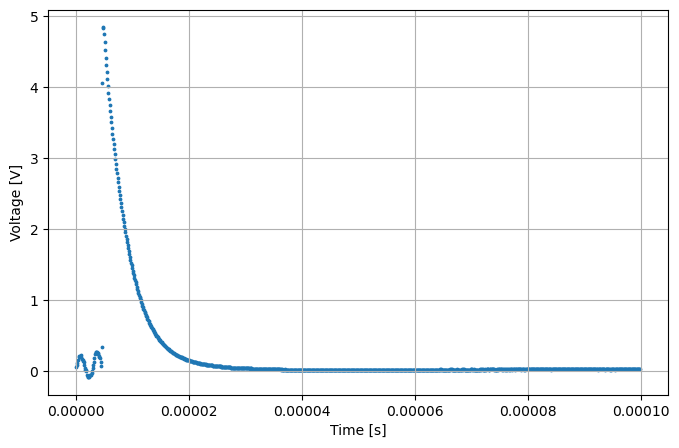

In [17]:
import numpy as np
import matplotlib.pyplot as plt

data1 = np.loadtxt(r"C:\Users\jupik\OneDrive\ドキュメント\data61.txt")

t = data[:,0]
V = data[:,1]

plt.figure(figsize=(8,5))

# 点で描画（点をかなり小さく）
plt.scatter(t, V, s=3)

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.grid(True)

plt.show()

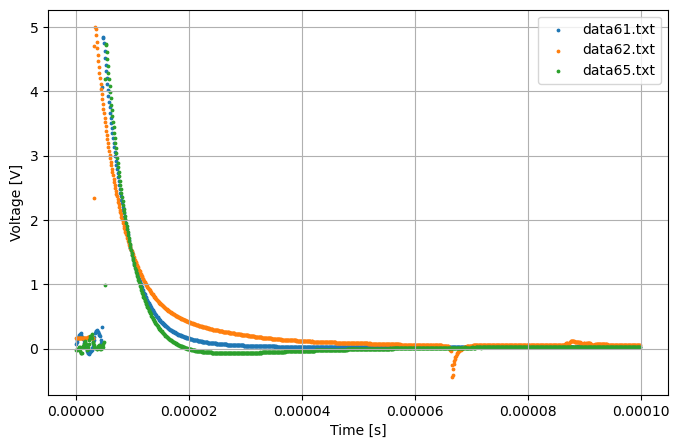

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ファイルリスト
files = [
    r"C:\Users\jupik\OneDrive\ドキュメント\data61.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data62.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data65.txt"
]

plt.figure(figsize=(8,5))

for file in files:
    data = np.loadtxt(file)
    t = data[:, 0]
    V = data[:, 1]

    # 点を小さくしてプロット
    plt.scatter(t, V, s=3, label=file.split("\\")[-1])

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.grid(True)
plt.legend()
plt.show()

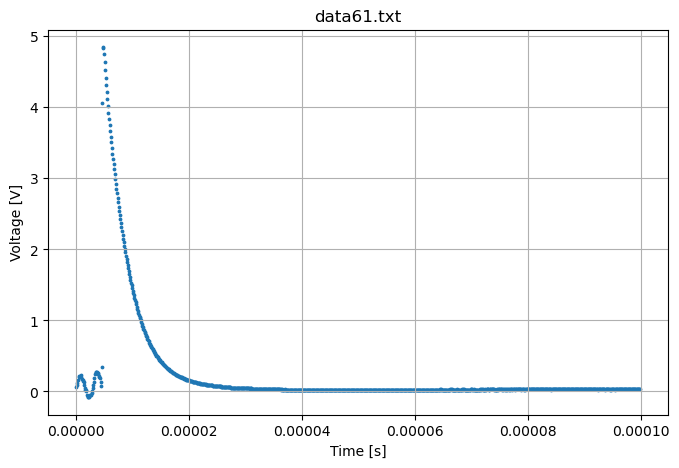

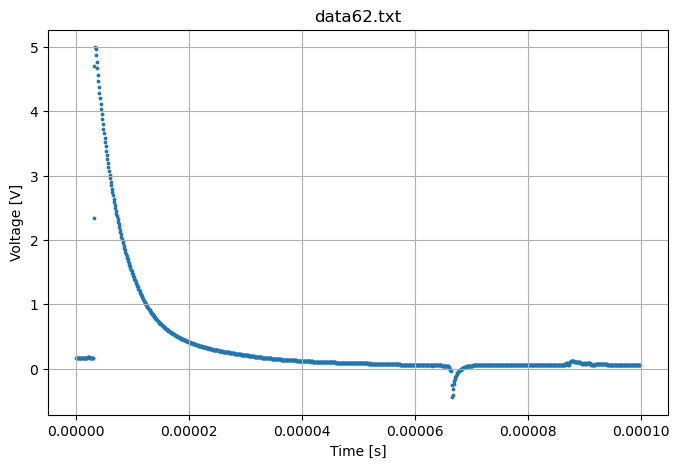

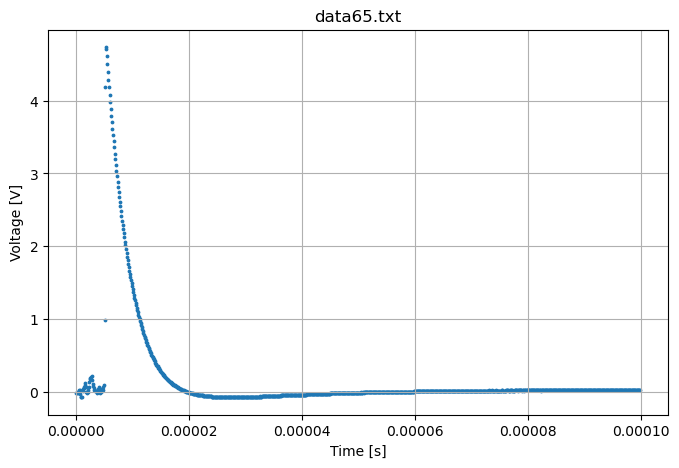

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ファイルリスト
files = [ r"C:\Users\jupik\OneDrive\ドキュメント\data61.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data62.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data65.txt"]

for file in files:
    data = np.loadtxt(file)
    t = data[:, 0]
    V = data[:, 1]

    plt.figure(figsize=(8,5))

    plt.scatter(t, V, s=3)

    plt.xlabel("Time [s]")
    plt.ylabel("Voltage [V]")
    plt.title(file.split("\\")[-1])
    plt.grid(True)

    plt.show()
    plt.close()  

In [25]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "Meiryo"

# =====================
# 理論値
# =====================

R = 220
L = 470e-6

alpha = R/(2*L)

beta = np.sqrt(
    alpha**2 - 1/(L*C)
)

tau1_theory = 1/(alpha - beta)
tau2_theory = 1/(alpha + beta)

print(f"理論時定数 τ = ({tau_theory:.3e} ± {tau_theory_err:.3e}) s")

# =====================
# データ読み込み
# =====================

data1 = np.loadtxt( r"C:\Users\jupik\OneDrive\ドキュメント\data61.txt")
data2 = np.loadtxt( r"C:\Users\jupik\OneDrive\ドキュメント\data62.txt")
data3 = np.loadtxt( r"C:\Users\jupik\OneDrive\ドキュメント\data65.txt")

datasets = [data1, data2, data3]

# =====================
# 解析
# =====================

taus = []
taus_fit = []

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i, data in enumerate(datasets):

    t = data[:, 0]
    V = data[:, 1]

    dV = np.gradient(V, t)
    idx0 = np.where(dV < -np.std(dV))[0][0]

    t0 = t[idx0]
    t_shift = t - t0

    mask = t_shift >= 0

    t_fit = t_shift[mask]
    V_fit =np.abs( V[mask])

    V0 = np.max(V_fit)
    B0 = np.min(V_fit)

    # =====================
    # 1/e法
    # =====================

    target = B0 + (V0 - B0) / np.e

    idx_tau = np.argmin(np.abs(V_fit - target))
    tau_exp = t_fit[idx_tau]

    taus.append(tau_exp)

    # =====================
    # フィッティング
    # =====================
    def overdamped(t, A1, tau1, A2, tau2, C):
        return ( A1 * np.exp(-t/tau1)+ A2 * np.exp(-t/tau2)+ C )
    popt, pcov = curve_fit(
        overdamped,
        t_fit,
        V_fit,
        p0=[
            3,          # A1
            5e-6,       # tau1
            2,          # A2
            2e-5,       # tau2
            0           # C
        ],
        maxfev=10000
    )
    
    A1_fit, tau1_fit, A2_fit, tau2_fit, C_fit = popt
    taus_fit.append(tau_fit)

    # =====================
    # 描画用
    # =====================

    t_plot = np.linspace(
        0,
        np.max(t_fit),
        2000
    )

    V_fitted = decay(
        t_plot,
        A_fit,
        tau_fit,
        B_fit
    )

    # μs表示

    t_shift_us = t_shift * 1e6
    t_plot_us = t_plot * 1e6

    tau_theory_us = tau_theory * 1e6
    tau_exp_us = tau_exp * 1e6
    tau_fit_us = tau_fit * 1e6

    print()
    print(f"測定データ {i+1}")
    print(f"1/e法時定数 = {tau_exp:.3e} s")
    print(f"τ1 = {tau1_fit:.3e} s")
    print(f"τ2 = {tau2_fit:.3e} s")
    print(f"オフセット電圧 = {B_fit:.3f} V")

    # =====================
    # グラフ
    # =====================

    axs[i].scatter(
        t_shift_us,
        V,
        s=0.5,
        label="測定値"
    )

    axs[i].plot(
        t_plot_us,
        V_fitted,
        lw=2,
        label=(
            f"τ1={tau1_fit*1e6:.2f} μs\n"
            f"τ2={tau2_fit*1e6:.2f} μs")
    )

    axs[i].plot(
        color="red",
        [],
        [],
        ' ',
        label=(
            f"フィット時定数\n"
            f"τ = {tau_fit_us:.2f} μs")
    )
    

    axs[i].set_title(
        f"測定データ {i+1}"
    )

    axs[i].set_xlabel(
        "放電開始からの時間 [μs]"
    )

    axs[i].set_ylabel(
        "コイル電圧 [V]"
    )

    axs[i].grid(True)

    axs[i].legend(
        fontsize=8,
        loc="upper right"
    )

# =====================
# 全体タイトル
# =====================

fig.suptitle(
    "LCR直列回路のコイル電圧減衰",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

# =====================
# 統計処理
# =====================

taus = np.array(taus)
taus_fit = np.array(taus_fit)

tau_mean = np.mean(taus)
tau_std = np.std(taus, ddof=1)

tau_fit_mean = np.mean(taus_fit)
tau_fit_std = np.std(taus_fit, ddof=1)

error = abs(
    tau_mean - tau_theory
) / tau_theory * 100

error_fit = abs(
    tau_fit_mean - tau_theory
) / tau_theory * 100

print()
print("----- 1/e法による時定数 -----")
print(f"測定1 = {taus[0]:.3e} s")
print(f"測定2 = {taus[1]:.3e} s")
print(f"測定3 = {taus[2]:.3e} s")
print(f"平均値 = {tau_mean:.3e} s")
print(f"標準偏差 = {tau_std:.3e} s")
print(f"理論値との相対誤差 = {error:.2f} %")

print()
print("----- 指数関数フィッティング -----")
print(f"測定1 = {taus_fit[0]:.3e} s")
print(f"測定2 = {taus_fit[1]:.3e} s")
print(f"測定3 = {taus_fit[2]:.3e} s")
print(f"平均値 = {tau_fit_mean:.3e} s")
print(f"標準偏差 = {tau_fit_std:.3e} s")
print(f"理論値との相対誤差 = {error_fit:.2f} %")

SyntaxError: positional argument follows keyword argument (2818620969.py, line 156)


測定データ1
1/e法 τ = 4.200e-06 s
フィット τ = 4.142e-06 s
オフセット = 0.027 V

測定データ2
1/e法 τ = 5.300e-06 s
フィット τ = 5.601e-06 s
オフセット = 0.090 V

測定データ3
1/e法 τ = 3.900e-06 s
フィット τ = 3.624e-06 s
オフセット = 0.017 V


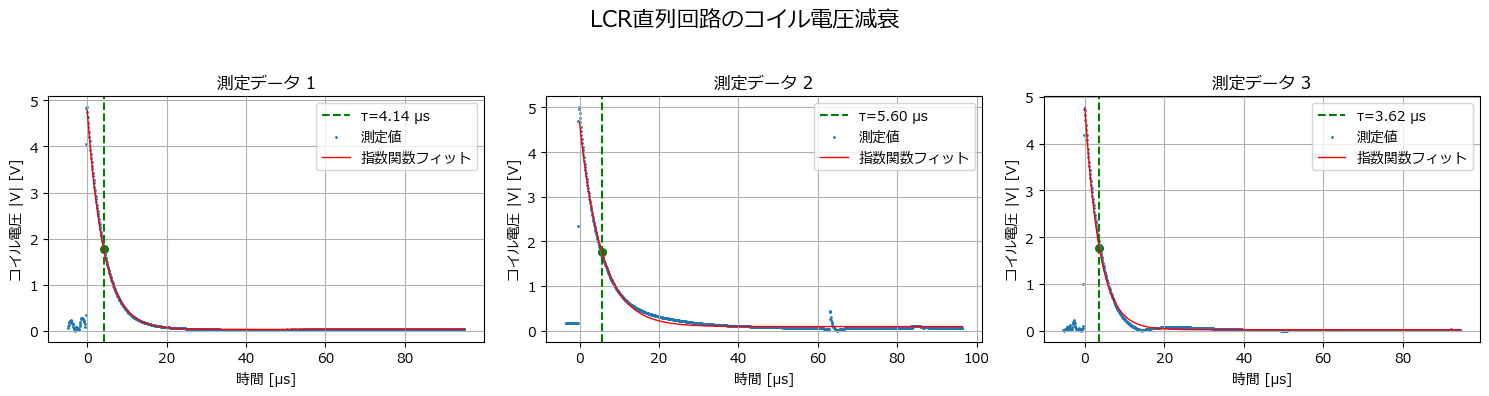


===== 1/e法 =====
平均 τ = 4.467e-06 s
標準偏差 = 7.371e-07 s

===== 指数関数フィット =====
平均 τ = 4.456e-06 s
標準偏差 = 1.025e-06 s

推定実効抵抗 R ≈ 150.0 Ω


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

# =====================
# データ読み込み
# =====================

files = [
    r"C:\Users\jupik\OneDrive\ドキュメント\data61.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data62.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data65.txt"
]

datasets = [np.loadtxt(file) for file in files]

# =====================
# フィット関数
# =====================

def decay(t, A, tau, B):
    return A * np.exp(-t / tau) + B

# =====================
# 保存用
# =====================

taus_1e = []
taus_fit = []

# =====================
# グラフ
# =====================

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i, data in enumerate(datasets):

    t = data[:, 0]
    V = data[:, 1]

    # -----------------
    # 放電開始点検出
    # -----------------

    dV = np.gradient(V, t)

    idx0 = np.where(
        dV < -np.std(dV)
    )[0][0]

    t0 = t[idx0]

    t_shift = t - t0

    mask = t_shift >= 0

    t_fit = t_shift[mask]

    # 絶対値を取る
    V_fit = np.abs(V[mask])

    V0 = np.max(V_fit)
    B0 = np.min(V_fit)

    # -----------------
    # 1/e法
    # -----------------

    target = B0 + (V0 - B0) / np.e

    idx_tau = np.argmin(
        np.abs(V_fit - target)
    )

    tau_exp = t_fit[idx_tau]

    taus_1e.append(tau_exp)

    # -----------------
    # 単指数フィット
    # -----------------

    popt, pcov = curve_fit(
        decay,
        t_fit,
        V_fit,
        p0=[
            V0 - B0,
            tau_exp,
            B0
        ],
        maxfev=10000
    )

    A_fit, tau_fit, B_fit = popt

    taus_fit.append(tau_fit)

    # -----------------
    # 描画用
    # -----------------

    t_plot = np.linspace(
        0,
        np.max(t_fit),
        2000
    )

    V_fitted = decay(
        t_plot,
        A_fit,
        tau_fit,
        B_fit
    )

    # μs表示

    t_shift_us = t_shift * 1e6
    t_plot_us = t_plot * 1e6

    tau_fit_us = tau_fit * 1e6

    axs[i].axvline(
        tau_fit_us,
        color="green",
        linestyle="--",
        linewidth=1.5,
        label=f"τ={tau_fit_us:.2f} μs"
    )

    V_tau = B_fit + A_fit/np.e

    axs[i].scatter(
        tau_fit_us,
        V_tau,
        s=30,
        color="green"
    )
    
    # -----------------
    # 出力
    # -----------------

    print()
    print(f"測定データ{i+1}")
    print(f"1/e法 τ = {tau_exp:.3e} s")
    print(f"フィット τ = {tau_fit:.3e} s")
    print(f"オフセット = {B_fit:.3f} V")

    # -----------------
    # グラフ
    # -----------------

    axs[i].scatter(
        t_shift_us,
        np.abs(V),
        s=1,
        label="測定値"
    )

    axs[i].plot(
        t_plot_us,
        V_fitted,
        color="red",
        lw=1,
        label=f"指数関数フィット"
    )

    axs[i].set_title(
        f"測定データ {i+1}"
    )

    axs[i].set_xlabel(
        "時間 [μs]"
    )

    axs[i].set_ylabel(
        "コイル電圧 |V| [V]"
    )

    axs[i].grid(True)

    axs[i].legend(
        fontsize=10
    )

# =====================
# 全体タイトル
# =====================

fig.suptitle(
    "LCR直列回路のコイル電圧減衰",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

# =====================
# 統計処理
# =====================

taus_1e = np.array(taus_1e)
taus_fit = np.array(taus_fit)

tau_1e_mean = np.mean(taus_1e)
tau_1e_std = np.std(taus_1e, ddof=1)

tau_fit_mean = np.mean(taus_fit)
tau_fit_std = np.std(taus_fit, ddof=1)

print()
print("===== 1/e法 =====")
print(f"平均 τ = {tau_1e_mean:.3e} s")
print(f"標準偏差 = {tau_1e_std:.3e} s")

print()
print("===== 指数関数フィット =====")
print(f"平均 τ = {tau_fit_mean:.3e} s")
print(f"標準偏差 = {tau_fit_std:.3e} s")

L = 470e-6
C = 0.1e-6

R_est = tau_fit_mean / C + L / tau_fit_mean

print()
print(f"推定実効抵抗 R ≈ {R_est:.1f} Ω")

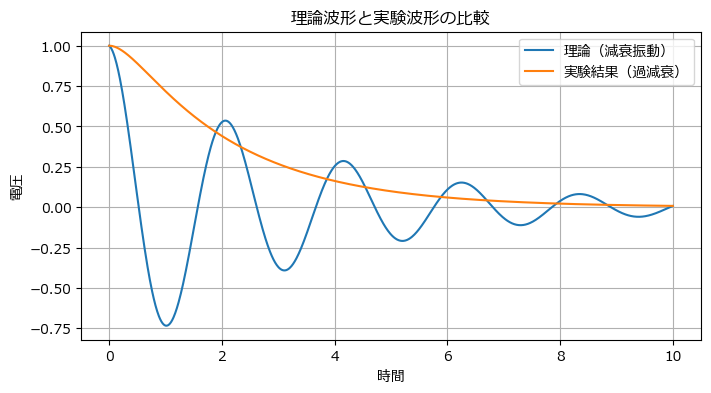

In [35]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 1000)

# 減衰振動
y1 = np.exp(-0.3*t) * np.cos(3*t)

# 過減衰
y2 = 1.2*np.exp(-0.5*t) - 0.2*np.exp(-3*t)

plt.figure(figsize=(8,4))

plt.plot(t, y1, label="理論（減衰振動）")
plt.plot(t, y2, label="実験結果（過減衰）")

plt.xlabel("時間")
plt.ylabel("電圧")
plt.title("理論波形と実験波形の比較")

plt.grid(True)
plt.legend()

plt.show()

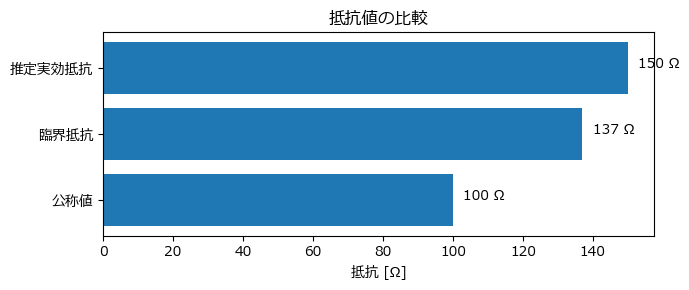

In [37]:
import matplotlib.pyplot as plt

labels = [
    "公称値",
    "臨界抵抗",
    "推定実効抵抗"
]

values = [
    100,
    137,
    150
]

plt.figure(figsize=(7,3))

plt.barh(labels, values)

plt.xlabel("抵抗 [Ω]")
plt.title("抵抗値の比較")

for i, v in enumerate(values):
    plt.text(v+3, i, f"{v} Ω")

plt.tight_layout()
plt.show()

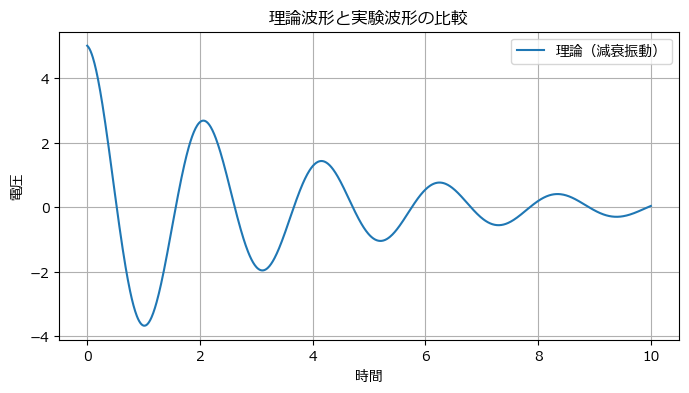

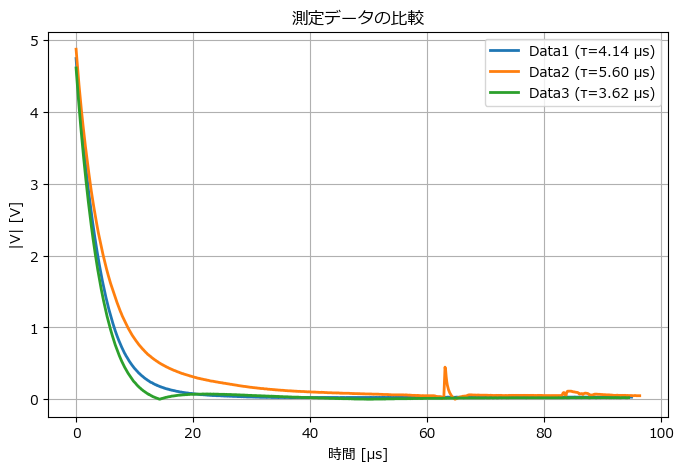

In [42]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 1000)

# 減衰振動
y1 = 5*np.exp(-0.3*t) * np.cos(3*t)

plt.figure(figsize=(8,4))

plt.plot(t, y1, label="理論（減衰振動）")
plt.xlabel("時間")
plt.ylabel("電圧")
plt.title("理論波形と実験波形の比較")

plt.grid(True)
plt.legend()

plt.show()
files = [
    r"C:\Users\jupik\OneDrive\ドキュメント\data61.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data62.txt",
    r"C:\Users\jupik\OneDrive\ドキュメント\data65.txt"
]

labels = [
    "Data1 (τ=4.14 μs)",
    "Data2 (τ=5.60 μs)",
    "Data3 (τ=3.62 μs)"
]

plt.figure(figsize=(8,5))

for file, label in zip(files, labels):

    data = np.loadtxt(file)

    t = data[:,0]
    V = np.abs(data[:,1])

    # 放電開始を0に合わせる
    dV = np.gradient(V, t)
    idx0 = np.where(dV < -np.std(dV))[0][0]

    t = t - t[idx0]

    mask = t >= 0

    plt.plot(
        t[mask]*1e6,
        V[mask],
        lw=2,
        label=label
    )

plt.xlabel("時間 [μs]")
plt.ylabel("|V| [V]")
plt.title("測定データの比較")
plt.grid(True)
plt.legend()

plt.show()